## Dataset

In [1]:
# Banknote.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('D:/NLP_CV/NLP/datasets/banknotes.csv')

In [7]:
df.shape

(1372, 5)

In [8]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [9]:
# input
x =df.drop('Class', axis=1)
# output
y = df['Class']

In [10]:
y.value_counts()

Class
0    762
1    610
Name: count, dtype: int64

In [11]:
y = y.map({0:'Original', 1:'Fake'})

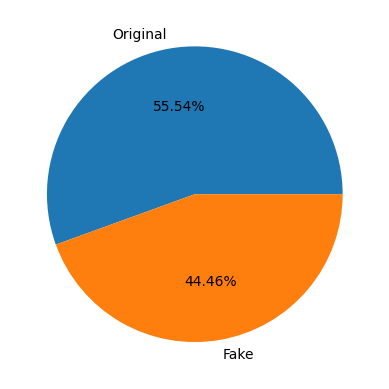

In [13]:
plt.pie(y.value_counts(), labels=y.value_counts().index, autopct='%2.2f%%');

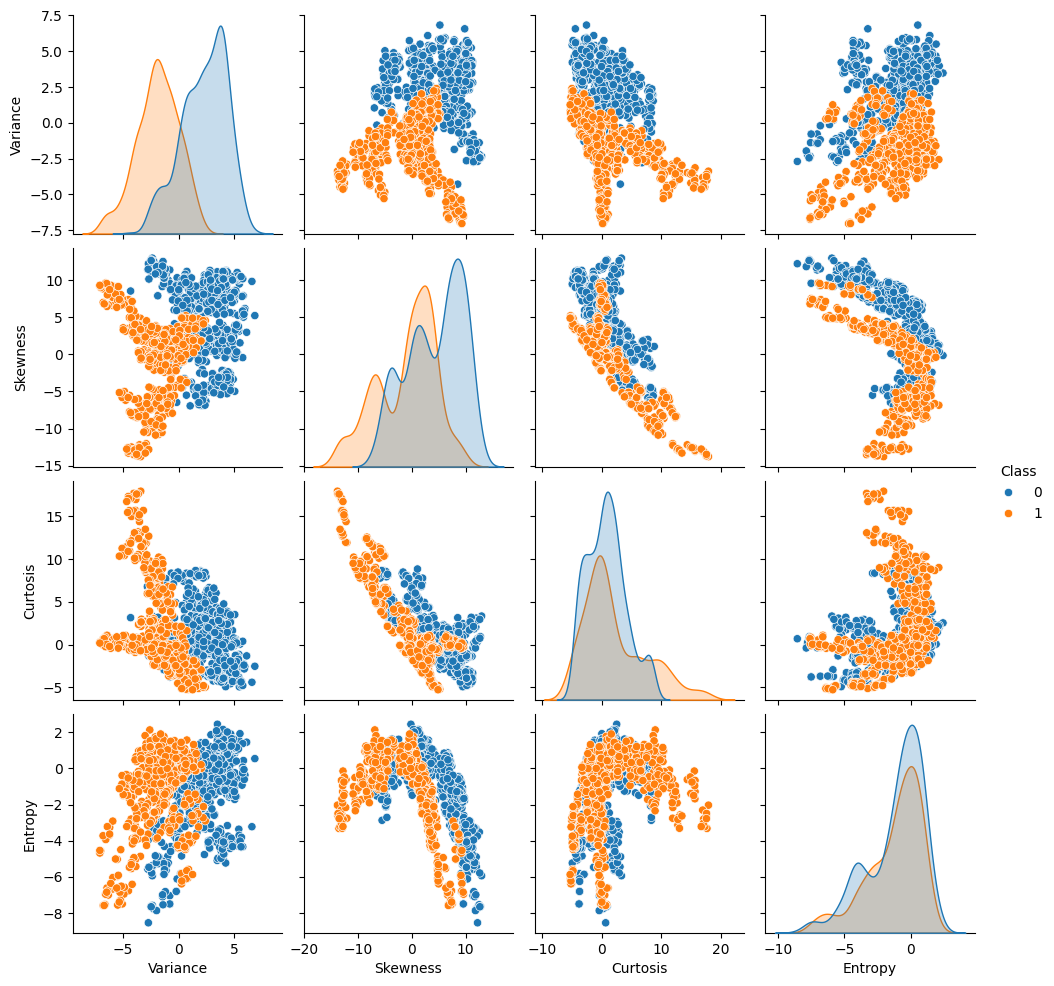

In [14]:
sns.pairplot(df, hue='Class')

#### Cross Validation

In [16]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train,y_test = train_test_split(x , y , random_state=0)

In [17]:
x_train.shape

(1029, 4)

In [18]:
x_test.shape

(343, 4)

In [19]:
#### Build the model

In [20]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
dt = DecisionTreeClassifier(random_state=0)

In [23]:
dt.fit(x_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
#### Evaluate the Classifier

Train accuracy: 1.0
Test accuracy:  0.9795918367346939

Classification report:
               precision    recall  f1-score   support

        Fake       0.97      0.98      0.98       148
    Original       0.98      0.98      0.98       195

    accuracy                           0.98       343
   macro avg       0.98      0.98      0.98       343
weighted avg       0.98      0.98      0.98       343



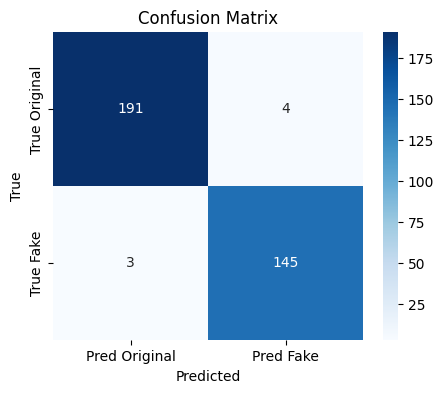

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions
y_pred = dt.predict(x_test)
y_train_pred = dt.predict(x_train)

# Metrics
print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy: ", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred, labels=['Original', 'Fake'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Original','Pred Fake'], yticklabels=['True Original','True Fake'])
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

In [27]:
dt.feature_importances_

array([0.62095248, 0.21106862, 0.14189251, 0.02608639])

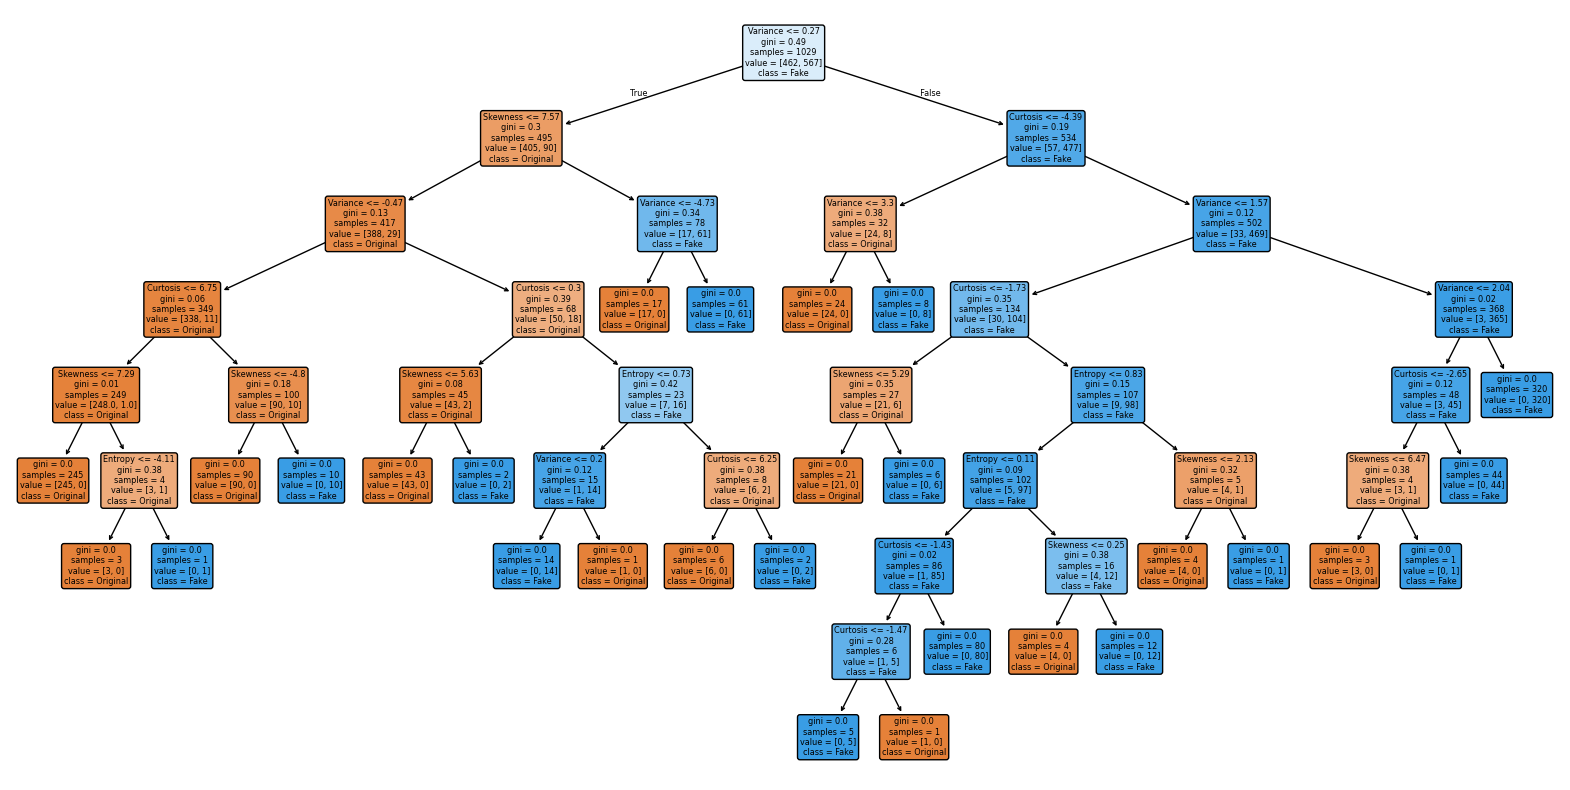

In [28]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=x.columns, class_names=['Original', 'Fake'], filled=True, rounded=True , precision=2)
plt.show()

In [29]:
df.iloc[12:]

,Variance,Skewness,Curtosis,Entropy,Class
12,1.89930,7.66250,0.15394,-3.11080,0
13,-1.57680,10.84300,2.54620,-2.93620,0
14,3.40400,8.72610,-2.99150,-0.57242,0
15,4.67650,-3.38950,3.48960,1.47710,0
16,2.67190,3.06460,0.37158,0.58619,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.45010,-0.55949,1
1368,-1.38870,-4.87730,6.47740,0.34179,1
1369,-3.75030,-13.45860,17.59320,-2.77710,1
1370,-3.56370,-8.38270,12.39300,-1.28230,1


In [30]:
newdf = pd.DataFrame(data=[[5.262, 3.9834, -1.55/2, 1.0183],
                           [-1.3995, -1.9162, 2.5154, 0.59912],
                           [-2.6989, 12.1984, 0.67661, -0.5482]],
                     columns=x.columns)

In [31]:
newdf

,Variance,Skewness,Curtosis,Entropy
0,5.2620,3.9834,-0.77500,1.01830
1,-1.3995,-1.9162,2.51540,0.59912
2,-2.6989,12.1984,0.67661,-0.54820


In [33]:
predictions = dt.predict(newdf)
predictions

array(['Original', 'Fake', 'Original'], dtype=object)